In [11]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [12]:
actual_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH"

params = {
    "fuelType": "WIND",
    "publishDateTimeFrom": "2024-01-01T00:00:00Z",
    "publishDateTimeTo": "2024-01-07T23:30:00Z"
}

actual_response = requests.get(actual_url, params=params)
actual_data = actual_response.json()["data"]

actual_df = pd.DataFrame(actual_data)

actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-07T23:30:00Z,2024-01-07T23:00:00Z,2024-01-07,47,WIND,4242
1,FUELHH,2024-01-07T23:00:00Z,2024-01-07T22:30:00Z,2024-01-07,46,WIND,4100
2,FUELHH,2024-01-07T22:30:00Z,2024-01-07T22:00:00Z,2024-01-07,45,WIND,3994
3,FUELHH,2024-01-07T22:00:00Z,2024-01-07T21:30:00Z,2024-01-07,44,WIND,4030
4,FUELHH,2024-01-07T21:30:00Z,2024-01-07T21:00:00Z,2024-01-07,43,WIND,3992


In [13]:
actual_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH"

params = {
    "fuelType": "WIND",
    "publishDateTimeFrom": "2024-01-01T00:00:00Z",
    "publishDateTimeTo": "2024-01-07T23:30:00Z"
}

actual_response = requests.get(actual_url, params=params)
actual_data = actual_response.json()["data"]

actual_df = pd.DataFrame(actual_data)

actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-07T23:30:00Z,2024-01-07T23:00:00Z,2024-01-07,47,WIND,4242
1,FUELHH,2024-01-07T23:00:00Z,2024-01-07T22:30:00Z,2024-01-07,46,WIND,4100
2,FUELHH,2024-01-07T22:30:00Z,2024-01-07T22:00:00Z,2024-01-07,45,WIND,3994
3,FUELHH,2024-01-07T22:00:00Z,2024-01-07T21:30:00Z,2024-01-07,44,WIND,4030
4,FUELHH,2024-01-07T21:30:00Z,2024-01-07T21:00:00Z,2024-01-07,43,WIND,3992


In [14]:
forecast_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR"

params = {
    "publishDateTimeFrom": "2024-01-01T00:00:00Z",
    "publishDateTimeTo": "2024-01-07T23:30:00Z"
}

forecast_response = requests.get(forecast_url, params=params)
forecast_data = forecast_response.json()["data"]

forecast_df = pd.DataFrame(forecast_data)

forecast_df.head()

,dataset,publishTime,startTime,generation
0,WINDFOR,2024-01-07T22:30:00Z,2024-01-07T21:00:00Z,4162
1,WINDFOR,2024-01-07T22:30:00Z,2024-01-07T22:00:00Z,4098
2,WINDFOR,2024-01-07T22:30:00Z,2024-01-07T23:00:00Z,4245
3,WINDFOR,2024-01-07T22:30:00Z,2024-01-08T00:00:00Z,4578
4,WINDFOR,2024-01-07T22:30:00Z,2024-01-08T01:00:00Z,4805


In [15]:
actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-07T23:30:00Z,2024-01-07 23:00:00+00:00,2024-01-07,47,WIND,4242
1,FUELHH,2024-01-07T23:00:00Z,2024-01-07 22:30:00+00:00,2024-01-07,46,WIND,4100
2,FUELHH,2024-01-07T22:30:00Z,2024-01-07 22:00:00+00:00,2024-01-07,45,WIND,3994
3,FUELHH,2024-01-07T22:00:00Z,2024-01-07 21:30:00+00:00,2024-01-07,44,WIND,4030
4,FUELHH,2024-01-07T21:30:00Z,2024-01-07 21:00:00+00:00,2024-01-07,43,WIND,3992


In [16]:
merged_df = pd.merge(
    actual_df[["startTime", "generation"]],
    forecast_df[["startTime", "generation"]],
    on="startTime",
    how="inner",
    suffixes=("_actual", "_forecast")
)

merged_df.head()

,startTime,generation_actual,generation_forecast
0,2024-01-07 23:00:00+00:00,4242,4245
1,2024-01-07 23:00:00+00:00,4242,4252
2,2024-01-07 23:00:00+00:00,4242,4566
3,2024-01-07 23:00:00+00:00,4242,4778
4,2024-01-07 23:00:00+00:00,4242,4791


In [17]:
merged_df["error"] = merged_df["generation_forecast"] - merged_df["generation_actual"]
merged_df["absolute_error"] = merged_df["error"].abs()

merged_df.head()

,startTime,generation_actual,generation_forecast,error,absolute_error
0,2024-01-07 23:00:00+00:00,4242,4245,3,3
1,2024-01-07 23:00:00+00:00,4242,4252,10,10
2,2024-01-07 23:00:00+00:00,4242,4566,324,324
3,2024-01-07 23:00:00+00:00,4242,4778,536,536
4,2024-01-07 23:00:00+00:00,4242,4791,549,549


In [18]:
mean_error = merged_df["error"].mean()
median_error = merged_df["error"].median()
p99_error = merged_df["absolute_error"].quantile(0.99)

print("Mean Error:", mean_error)
print("Median Error:", median_error)
print("P99 Error:", p99_error)

Mean Error: 605.7968181818181
Median Error: 739.0
P99 Error: 4614.0199999999995


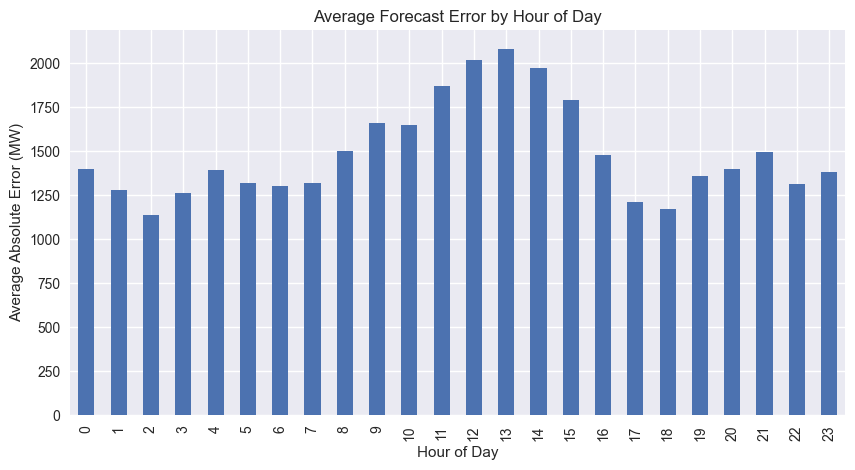

In [19]:
#Error vs time delay 
merged_df["hour"] = merged_df["startTime"].dt.hour

hourly_error = merged_df.groupby("hour")["absolute_error"].mean()

hourly_error.plot(kind="bar", figsize=(10,5), title="Average Forecast Error by Hour of Day")

plt.xlabel("Hour of Day")
plt.ylabel("Average Absolute Error (MW)")
plt.show()

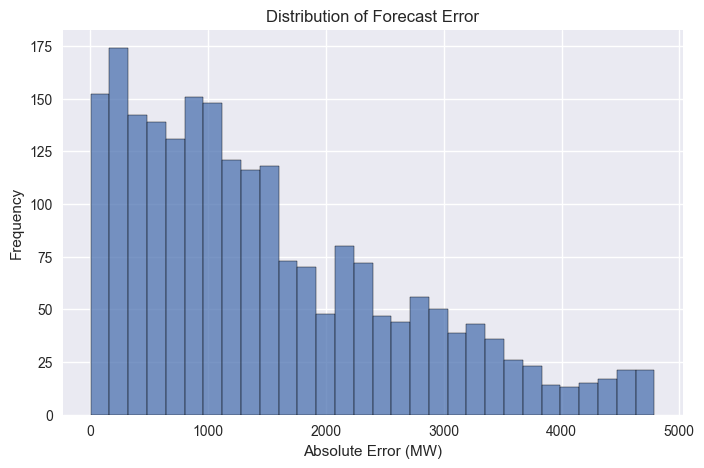

In [21]:
#Error distribution
plt.figure(figsize=(8,5))

sns.histplot(merged_df["absolute_error"], bins=30)

plt.title("Distribution of Forecast Error")
plt.xlabel("Absolute Error (MW)")
plt.ylabel("Frequency")

plt.show()

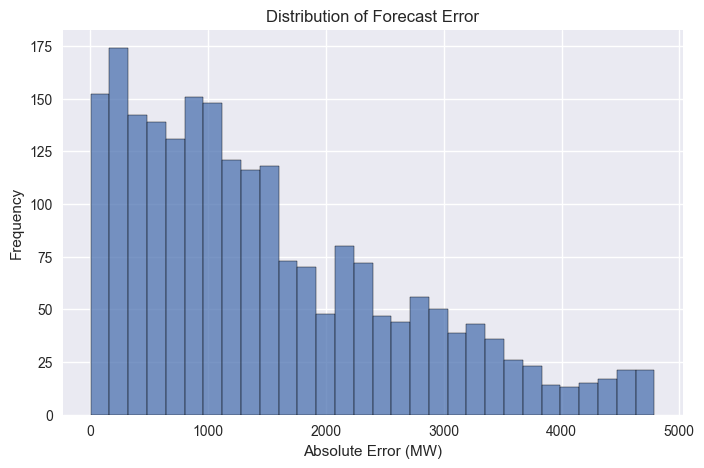

In [22]:
#Reliable wind generation
plt.figure(figsize=(8,5))

sns.histplot(merged_df["absolute_error"], bins=30)

plt.title("Distribution of Forecast Error")
plt.xlabel("Absolute Error (MW)")
plt.ylabel("Frequency")

plt.show()

In [23]:
actual_generation = actual_df["generation"]

p10 = actual_generation.quantile(0.10)
p50 = actual_generation.quantile(0.50)
p90 = actual_generation.quantile(0.90)

print("P10 Generation:", p10)
print("Median Generation:", p50)
print("P90 Generation:", p90)

P10 Generation: 4376.5
Median Generation: 7041.5
P90 Generation: 11901.5


### Reliable Wind Generation Analysis

Wind generation varies depending on weather conditions.
To estimate how much wind power can reliably meet electricity demand,
we examine the distribution of historical wind generation values.

The P10 generation represents the level of generation exceeded 90%
of the time. Therefore, approximately P10 MW of wind power can be
considered reliably available to meet electricity demand.

This provides a conservative and reliable estimate of wind power capacity.